In [6]:
# ===== ЯЧЕЙКА 1 — Импорты и повтор подготовки =====
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

df = pd.read_csv('../data/tenders_clean.csv')

for col in ['Contracting_Authority', 'CPV_Code']:
    freq = df[col].value_counts(normalize=True)
    df[col + '_freq'] = df[col].map(freq)
    df.drop(columns=[col], inplace=True)

cat_cols = ['Type', 'Contract_Type', 'Procedure_Type',
            'Contracting_Authority_Activity_Type',
            'Award_Criteria_Type', 'Currency']
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['single_bidder'])
y = df['single_bidder']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

spw = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    scale_pos_weight=spw, random_state=42,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
print("Модель обучена, готовим SHAP")


Модель обучена, готовим SHAP


In [7]:
# ===== ЯЧЕЙКА 2 — Вычисление SHAP-значений =====
X_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)
print("SHAP-значения вычислены, форма:", shap_values.shape)

SHAP-значения вычислены, форма: (2000, 8)


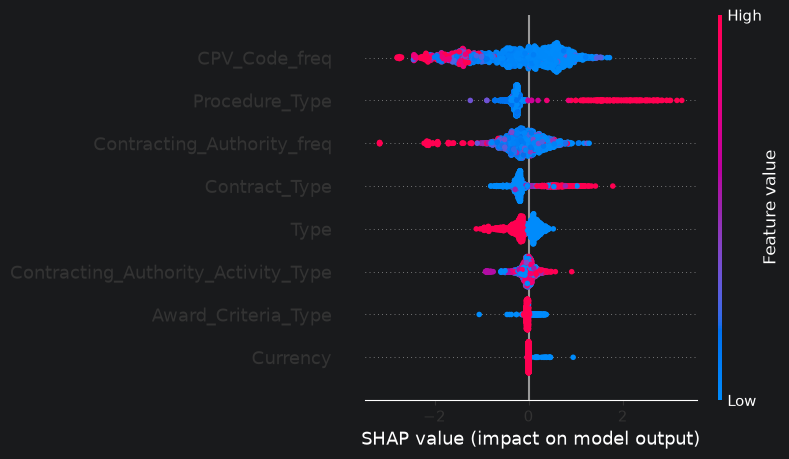

Сохранено: shap_summary.png


In [8]:
# ===== ЯЧЕЙКА 3 — SHAP Summary Plot (главный график) =====
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Сохранено: shap_summary.png")

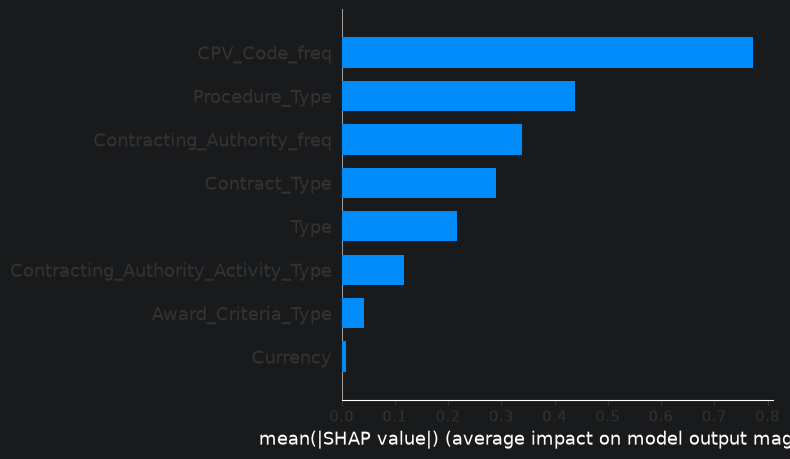

Сохранено: shap_bar.png


In [10]:
# ===== ЯЧЕЙКА 4 — SHAP Bar Plot (средняя важность) =====
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print("Сохранено: shap_bar.png")

In [11]:
# ===== ЯЧЕЙКА 5 — Сохранение финальной модели =====
import joblib
joblib.dump(xgb, '../single_bidder_model.pkl')
print("Модель сохранена: single_bidder_model.pkl")

Модель сохранена: single_bidder_model.pkl
